# DDPM: Training a Diffusion Model on MNIST

This notebook implements a DDPM (Denoising Diffusion Probabilistic Model).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 1. Noise Schedule

We use a linear schedule for $\beta_t$ from $\beta_1 = 0.0001$ to $\beta_T = 0.02$.

Recall:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{i=1}^{t} \alpha_i$

In [2]:
class NoiseSchedule:
    def __init__(self, T=1000, beta_1=0.0001, beta_T=0.02, device='cpu'):
        self.T = T
        self.device = device

        self.beta = torch.linspace(beta_1, beta_T, T, device=device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        self.alpha_bar_prev = F.pad(self.alpha_bar[:-1], (1, 0), value=1.0)

        # For sampling
        self.sigma2 = (1 - self.alpha) * (1 - self.alpha_bar_prev) / (1 - self.alpha_bar)
        self.sigma = torch.sqrt(self.sigma2)

T = 1000
schedule = NoiseSchedule(T=T, device=device)

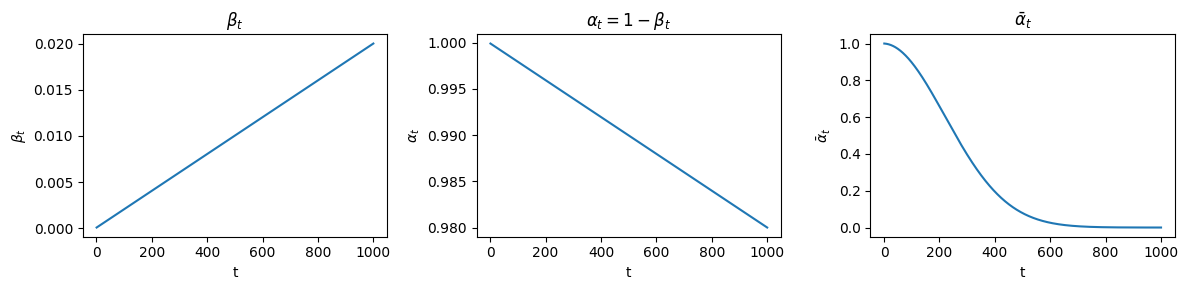

In [8]:
# Plot the schedule
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
t = np.arange(1, T+1)
axes[0].plot(t, schedule.beta.cpu().numpy())
axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$\beta_t$'); axes[0].set_title(r'$\beta_t$')
axes[1].plot(t, schedule.alpha.cpu().numpy())
axes[1].set_xlabel('t'); axes[1].set_ylabel(r'$\alpha_t$'); axes[1].set_title(r'$\alpha_t = 1 - \beta_t$')
axes[2].plot(t, schedule.alpha_bar.cpu().numpy())
axes[2].set_xlabel('t'); axes[2].set_ylabel(r'$\bar{\alpha}_t$'); axes[2].set_title(r'$\bar{\alpha}_t$')
plt.tight_layout()
plt.show()

## 2. Forward Process

The forward process adds noise to data:
$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \varepsilon, \quad \varepsilon \sim N(0, I)$$

In [9]:
def forward_process(x_0, t, schedule):
    """x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon"""
    epsilon = torch.randn_like(x_0)
    alpha_bar_t = schedule.alpha_bar[t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * epsilon
    return x_t, epsilon

## 3. Model Architecture

We use a U-Net with time embedding. The model predicts $\hat{\varepsilon}_\theta(x_t, t)$.

In [10]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class ResidualBlock(nn.Module):
    """Residual block with time embedding."""
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.dropout = nn.Dropout(dropout)

        # Skip connection if channels change
        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)

        # Add time embedding
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]

        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)

        return h + self.skip(x)


class AttentionBlock(nn.Module):
    """Self-attention block."""
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        b, c, h, w = x.shape

        x_norm = self.norm(x)
        q = self.q(x_norm).view(b, c, -1)  # (b, c, h*w)
        k = self.k(x_norm).view(b, c, -1)
        v = self.v(x_norm).view(b, c, -1)

        # Attention: softmax(Q^T K / sqrt(d)) V^T
        attn = torch.bmm(q.transpose(1, 2), k) * self.scale  # (b, h*w, h*w)
        attn = F.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.transpose(1, 2))  # (b, c, h*w)
        out = out.view(b, c, h, w)

        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net for MNIST with ~5M parameters.

    Architecture:
    - Encoder: 28→14→7 with channels 128→256→256
    - Attention at 7×7
    - 2 residual blocks per resolution
    """
    def __init__(self, in_channels=1, base_channels=128, time_emb_dim=256):
        super().__init__()

        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # Initial conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        # Encoder
        # Level 1: 28×28, 128 channels
        self.down1_block1 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.down1_block2 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.down1 = Downsample(base_channels)

        # Level 2: 14×14, 256 channels
        self.down2_block1 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down2_block2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.down2 = Downsample(base_channels * 2)

        # Level 3: 7×7, 256 channels + attention
        self.down3_block1 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.down3_attn = AttentionBlock(base_channels * 2)
        self.down3_block2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        # Bottleneck: 7×7
        self.mid_block1 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.mid_attn = AttentionBlock(base_channels * 2)
        self.mid_block2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        # Decoder
        # Level 3: 7×7 (with skip from down3)
        self.up3_block1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim)
        self.up3_attn = AttentionBlock(base_channels * 2)
        self.up3_block2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.up3 = Upsample(base_channels * 2)

        # Level 2: 14×14 (with skip from down2)
        self.up2_block1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim)
        self.up2_block2 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim)
        self.up2 = Upsample(base_channels)

        # Level 1: 28×28 (with skip from down1)
        self.up1_block1 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim)
        self.up1_block2 = ResidualBlock(base_channels, base_channels, time_emb_dim)

        # Output
        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_conv = nn.Conv2d(base_channels, in_channels, 3, padding=1)

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_mlp(t)

        # Initial conv
        x = self.init_conv(x)

        # Encoder
        d1 = self.down1_block1(x, t_emb)
        d1 = self.down1_block2(d1, t_emb)  # 28×28, 128ch

        d2 = self.down1(d1)
        d2 = self.down2_block1(d2, t_emb)
        d2 = self.down2_block2(d2, t_emb)  # 14×14, 256ch

        d3 = self.down2(d2)
        d3 = self.down3_block1(d3, t_emb)
        d3 = self.down3_attn(d3)
        d3 = self.down3_block2(d3, t_emb)  # 7×7, 256ch

        # Bottleneck
        h = self.mid_block1(d3, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)  # 7×7, 256ch

        # Decoder
        h = torch.cat([h, d3], dim=1)  # 7×7, 512ch
        h = self.up3_block1(h, t_emb)
        h = self.up3_attn(h)
        h = self.up3_block2(h, t_emb)
        h = self.up3(h)  # 14×14, 256ch

        h = torch.cat([h, d2], dim=1)  # 14×14, 512ch
        h = self.up2_block1(h, t_emb)
        h = self.up2_block2(h, t_emb)
        h = self.up2(h)  # 28×28, 128ch

        h = torch.cat([h, d1], dim=1)  # 28×28, 256ch
        h = self.up1_block1(h, t_emb)
        h = self.up1_block2(h, t_emb)  # 28×28, 128ch

        # Output
        h = F.silu(self.out_norm(h))
        return self.out_conv(h)


# Test
model = UNet().to(device)
x_test = torch.randn(4, 1, 28, 28, device=device)
t_test = torch.randint(0, T, (4,), device=device).float()
out = model(x_test, t_test)
print(f"Input: {x_test.shape}, Output: {out.shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Input: torch.Size([4, 1, 28, 28]), Output: torch.Size([4, 1, 28, 28])
Parameters: 16,775,937


## 4. Data

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale to [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print(f"Dataset: {len(train_dataset)} images")
print(f"Batches per epoch: {len(train_loader)}")

Dataset: 60000 images
Batches per epoch: 469


## 5. Training

Using the simplified $\varepsilon$-prediction objective:
$$L_{\mathrm{simple}}(\theta) = \mathbb{E}_{t, x_0, \varepsilon}\left[\|\varepsilon - \hat{\varepsilon}_\theta(x_t, t)\|^2\right]$$

In [12]:
def train_step(model, x_0, schedule, optimizer):
    optimizer.zero_grad()

    batch_size = x_0.shape[0]
    t = torch.randint(0, schedule.T, (batch_size,), device=x_0.device)

    x_t, epsilon = forward_process(x_0, t, schedule)
    epsilon_pred = model(x_t, t.float())

    loss = F.mse_loss(epsilon_pred, epsilon)

    loss.backward()
    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return loss.item()

Epoch 1/15: 100%|██████████| 469/469 [00:27<00:00, 16.98it/s, loss=0.0385]


Epoch 1/15, Loss: 0.0575, LR: 0.000198


Epoch 2/15: 100%|██████████| 469/469 [00:27<00:00, 17.21it/s, loss=0.0323]


Epoch 2/15, Loss: 0.0289, LR: 0.000191


Epoch 3/15: 100%|██████████| 469/469 [00:27<00:00, 17.01it/s, loss=0.0269]


...

Epoch 13/15, Loss: 0.0218, LR: 0.000009


Epoch 14/15: 100%|██████████| 469/469 [00:27<00:00, 17.18it/s, loss=0.0182]


Epoch 14/15, Loss: 0.0215, LR: 0.000002


Epoch 15/15: 100%|██████████| 469/469 [00:27<00:00, 17.14it/s, loss=0.0252]


Epoch 15/15, Loss: 0.0216, LR: 0.000000


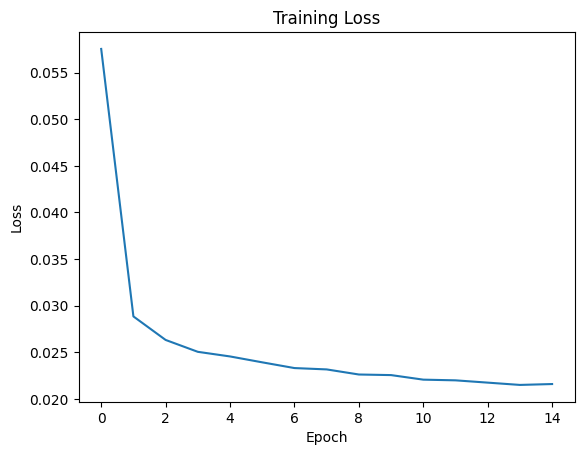

In [18]:
# Training
model = UNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

num_epochs = 15
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x_0, _ in pbar:
        x_0 = x_0.to(device)
        loss = train_step(model, x_0, schedule, optimizer)
        epoch_losses.append(loss)
        pbar.set_postfix({'loss': f'{loss:.4f}'})

    scheduler.step()
    avg_loss = np.mean(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.show()

## 6. Sampling

Sampling algorithm:
1. $x_T \sim N(0, I)$
2. For $t = T, \ldots, 1$:
   - $z \sim N(0, I)$ if $t > 1$, else $z = 0$
   - $x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}} \hat{\varepsilon}_\theta(x_t, t) \right) + \sigma_t z$
3. Return $x_0$

In [19]:
@torch.no_grad()
def sample(model, schedule, n_samples=16, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(n_samples, *image_size, device=schedule.device)

    for t in tqdm(reversed(range(schedule.T)), total=schedule.T, desc="Sampling"):
        t_batch = torch.full((n_samples,), t, device=schedule.device, dtype=torch.float)

        epsilon_pred = model(x, t_batch)

        alpha_t = schedule.alpha[t]
        alpha_bar_t = schedule.alpha_bar[t]
        sigma_t = schedule.sigma[t]

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = 0

        x = (1 / torch.sqrt(alpha_t)) * (x - (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t) * epsilon_pred) + sigma_t * z

    x = torch.clamp(x, -1, 1)
    x = (x + 1) / 2
    return x

Sampling: 100%|██████████| 1000/1000 [00:10<00:00, 95.04it/s]


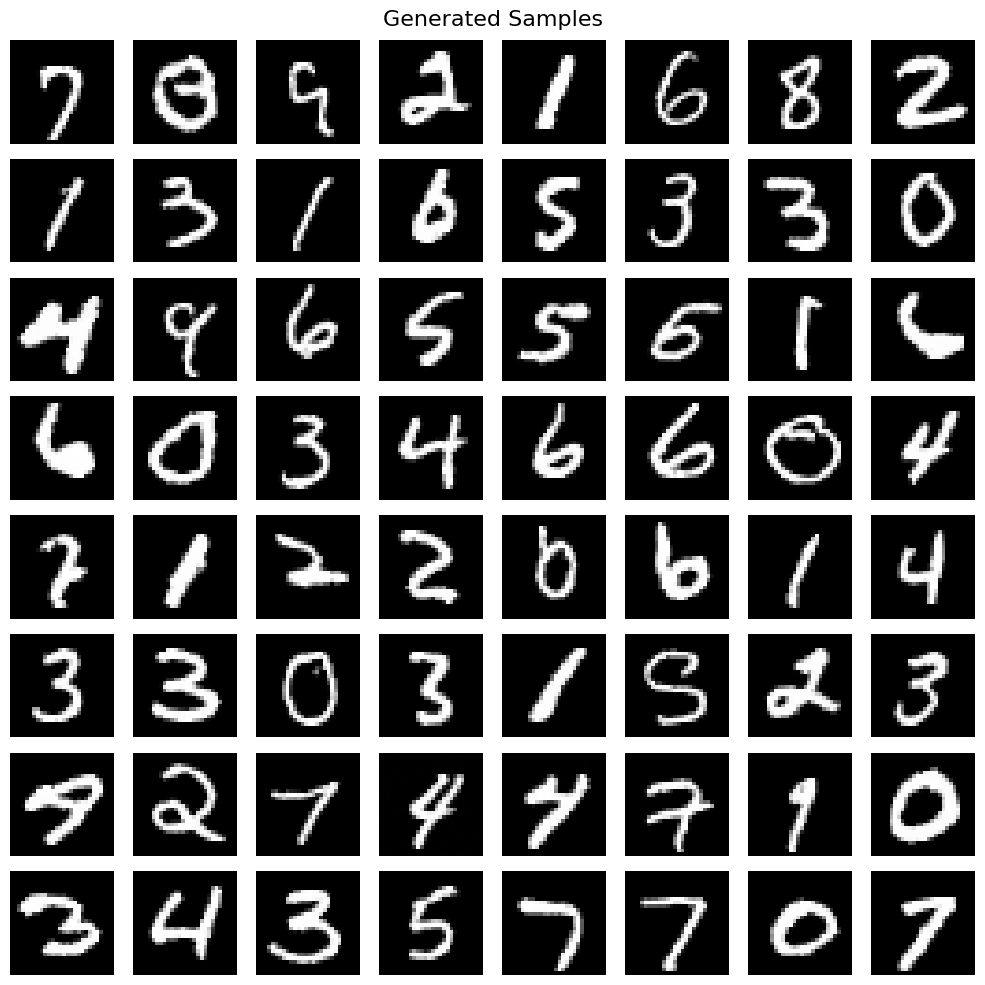

In [20]:
# Generate samples
samples = sample(model, schedule, n_samples=64)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0].cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle('Generated Samples', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Visualize the Denoising Process

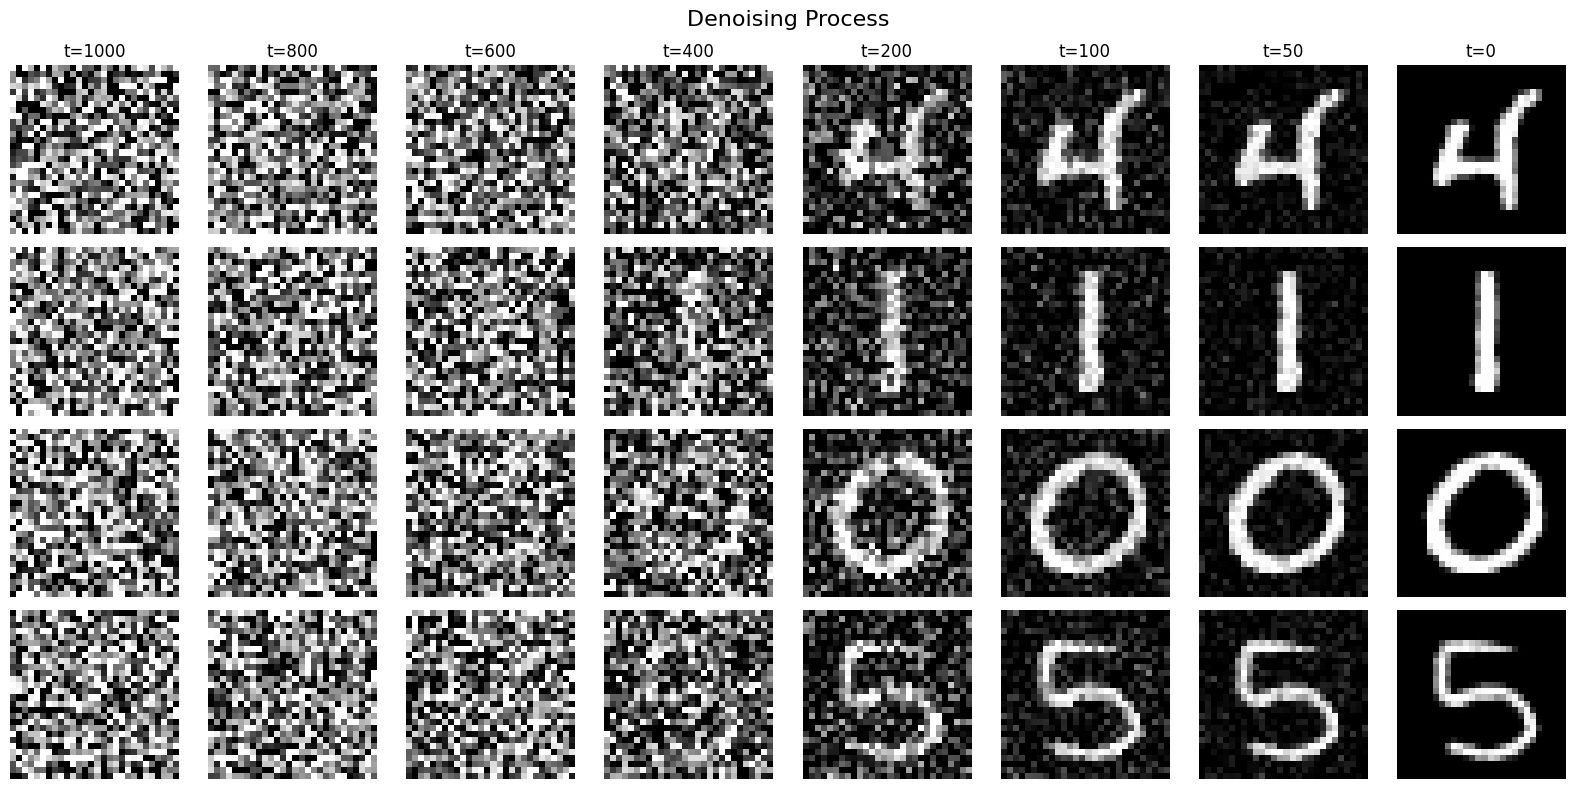

In [23]:
@torch.no_grad()
def sample_with_trajectory(model, schedule, n_samples=1, save_steps=[1000, 800, 600, 400, 200, 100, 50, 0]):
    model.eval()

    x = torch.randn(n_samples, 1, 28, 28, device=schedule.device)
    trajectory = [(1000, x.clone())]

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((n_samples,), t, device=schedule.device, dtype=torch.float)
        epsilon_pred = model(x, t_batch)

        alpha_t = schedule.alpha[t]
        alpha_bar_t = schedule.alpha_bar[t]
        sigma_t = schedule.sigma[t]

        z = torch.randn_like(x) if t > 0 else 0
        x = (1 / torch.sqrt(alpha_t)) * (x - (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t) * epsilon_pred) + sigma_t * z

        if t in save_steps:
            trajectory.append((t, x.clone()))

    return trajectory

# Visualize
trajectory = sample_with_trajectory(model, schedule, n_samples=4)

fig, axes = plt.subplots(4, len(trajectory), figsize=(2*len(trajectory), 8))
for row in range(4):
    for col, (t, imgs) in enumerate(trajectory):
        img = torch.clamp(imgs[row, 0], -1, 1).cpu().numpy()
        img = (img + 1) / 2
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={t}')
plt.suptitle('Denoising Process', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Save Model

In [22]:
# Save
torch.save(model.state_dict(), 'ddpm_mnist.pt')
print("Model saved to ddpm_mnist.pt")

# To load later:
# model = UNet().to(device)
# model.load_state_dict(torch.load('ddpm_mnist.pt'))

Model saved to ddpm_mnist.pt
